[[6,1 - Smoothing Masks and Scale Space]] $\leftarrow$ Back

---
# 1) What is the Gaussian Mask?
Gaussian mask is a 2D convolution mask which...
- "blurs" the image.
- removes detail and noise from the image.

It is similar to the averaging mask but the elements of the mask are produced differently.
- Uses the Gaussian distribution instead.

# 2) How to form a Gaussian Mask
The Gaussian distribution's formula is...
$$
f(x)=\frac{1}{\sqrt{2 \pi}\sigma}e^{-\frac{1}{2}\biggr(\frac{x-\mu}{\sigma}\biggr)^2}
$$
The 2 dimensional Gaussian distribution's formula is:
$$
f(x,y)=\frac{1}{\sqrt{2 \pi}\sigma}e^{-\frac{1}{2}\biggr(\frac{x+y-\mu}{\sigma}\biggr)^2}
$$
To form a Gaussian mask using the 2D gaussian distribution formula, the following assumptions are made:
1) Assume the distribution has a mean of 0 ($\mu = 0$). 
	- Is therefore centred at x=0.

The standard deviation, $\sigma$, is a chosen value.
- $\sigma$ controls how blurry the image, post-convolution, will be.
- As $\sigma \rightarrow \infty$, the mask's size must increase to capture the Gaussian distribution's tails.

Mask's size MUST be odd: allows there to be a centre point which will be the point the Gaussian distribution is centred about.
$$
M_{N^2} | N\in\{x|\forall i, x=2i+1\}
$$
- Rule of thumb: N should be $\geq 2\cdot CEIL(3\sigma) + 1$
	- Ensures that enough of the Gaussian distribution is captured by the mask such that the edges of the mask are close to 0

To populate elements of the Gaussian mask, you first populate it with unnormalised elements using the Gaussian distribution formula.
- Ignore the first coefficient, keep the exponential coefficient.
$$
weight(x,y)=e^{-\frac{x^2+y^2}{2\sigma^2}}
$$
$$
distCentre(p)=p-\frac{N-1}{2}
$$
```pseudocode
# POPULATE GAUSSIAN MASK WITH UNNORMALISED WEIGHTS:
for i <- 0 to N-1 do:
	for j <- 0 to N-1 do:
		M[i][j] = weight(distCentre(i), distCentre(j))
```

Now, normalise the elements of the Gaussian mask:
- DONE BY MODIFYING THE ABOVE PSEUDOCODE: CALCULATE SUM OF WEIGHTS AND ASSIGN WEIGHTS IN ONE LOOP
```psuedocode
# POPULATE GAUSSIAN MASK WITH UNNORMALISED WEIGHTS:
weightSum <- 0
for i <- 0 to N-1 do:
	for j <- 0 to N-1 do:
		M[i][j] <- weight(distCentre(i), distCentre(j))
		weightSum <- weightSum + M[i][j]
		
# NORMALISE GAUSSIAN MASK
for i <- 0 to N-1 do:
	for j <- 0 to N-1 do:
		M[i][j] <- M[i][j] / weightSum
```

# 3) Example in Python

[[0.00296902 0.01330621 0.02193823 0.01330621 0.00296902]
 [0.01330621 0.0596343  0.09832033 0.0596343  0.01330621]
 [0.02193823 0.09832033 0.16210282 0.09832033 0.02193823]
 [0.01330621 0.0596343  0.09832033 0.0596343  0.01330621]
 [0.00296902 0.01330621 0.02193823 0.01330621 0.00296902]]


<string>:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  # For single expressions, we want to capture and display the result


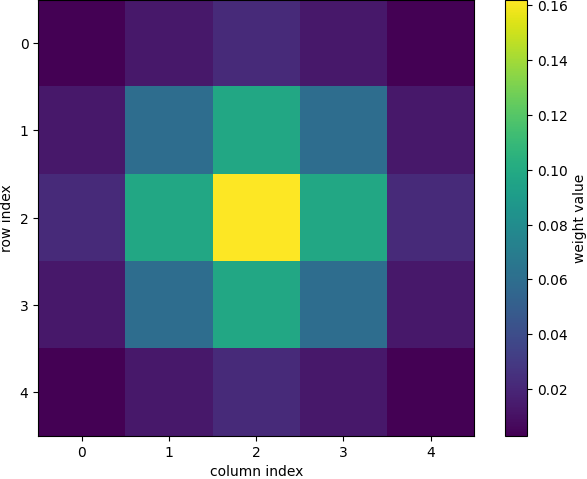

In [2]:
import numpy
import matplotlib.pyplot as pyplot

def calculateWeight(i:int, j:int, rowCentre:int, colCentre:int, stdDev:float)->float:
	return numpy.exp(-((i-rowCentre)**2+(j-colCentre)**2)/(2*(stdDev**2)))

def buildGaussianMask(rowSize:int, colSize:int, stdDev:float) -> numpy.ndarray:
	gaussianMask = numpy.zeros((rowSize, colSize))
	
	rowCentre = (rowSize - 1)/2
	colCentre = (colSize - 1)/2
	
	weightedSum = 0.0
	
	for i in range(rowSize):
		for j in range(colSize):
			gaussianMask[i, j] = calculateWeight(i, j, rowCentre, colCentre, stdDev)
			weightedSum += gaussianMask[i, j]
			
	return gaussianMask/weightedSum
	

gaussianMask = buildGaussianMask(5, 5, 1)
print(gaussianMask)

pyplot.imshow(gaussianMask, cmap="viridis", interpolation="nearest")
pyplot.colorbar(label="weight value")
pyplot.xlabel("column index")
pyplot.ylabel("row index")

pyplot.show()